KeyError: 'loss_media_val'

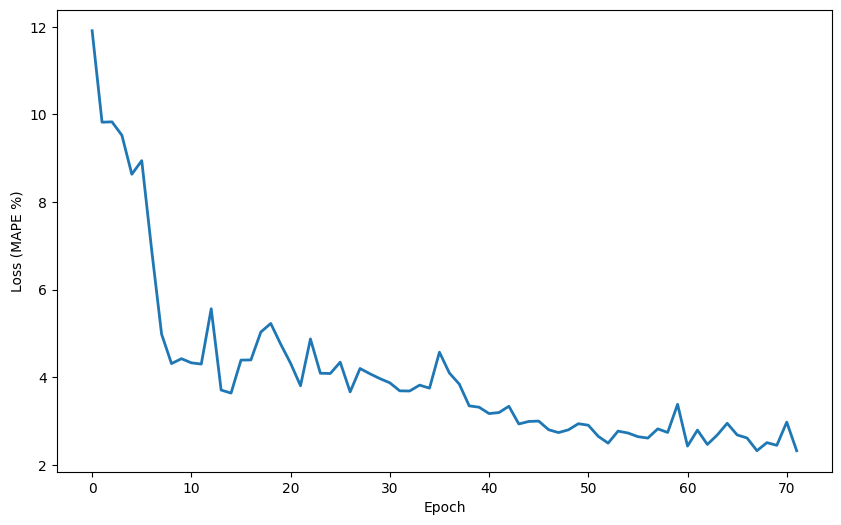

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los datos del CSV
# csv_path = './GNN-model/HQoS_new_model/oranallcfgs_ckpt32v2/learning_curve_v2.csv'
# # csv_path = './RouteNet-Fermi/HQoS_with_embeddings/oranallcfgs_ckpt/learning_curve.csv'
csv_path = './RouteNet-Fermi/HQoS/Fix_Normalization_con_LOGS/loss_media_por_epoch.csv'
# csv_path = './RouteNet-Fermi/all_mixed/AFTER_A_WEEK/learning_curve02.csv'
# csv_path = './RouteNet-Fermi/all_mixed/ckpt_oran-sensing-case2-20lr_0.001_fixed/learning_curve02.csv'
df = pd.read_csv(csv_path)
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Eje Primario (Loss y Val Loss) ---
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MAPE %)', color='black')
ax1.plot(df['epoch'], df['loss_media_train'], label='Entrenamiento (Loss)', color='tab:blue', linewidth=2)
ax1.plot(df['epoch'], df['loss_media_val'], label='Validación (Val Loss)', color='tab:orange', linestyle='--', linewidth=2)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.axhline(y=5, color='black', linestyle='--', linewidth=1, label = "GOAL (5%)") 
ax1.axhline(y=3, color='black', linestyle='--', linewidth=1, label = "GOAL (3%)") 
ax1.axhline(y=2, color='black', linestyle='--', linewidth=1, label = "GOAL (2%)") 
# --- Eje Secundario (Learning Rate) ---
ax2 = ax1.twinx() # Crea el segundo eje compartiendo el eje X
ax2.set_ylabel('Learning Rate', color='tab:green')
ax2.step(df['epoch'], df['lr'], label='Learning Rate', color='tab:green', where='post')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Ajustar los rangos para que se vea bien
ax2.set_ylim(0, df['lr'].max() * 1.1)

# Combinar las leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Curva de Aprendizaje con Monitoreo de LR')
plt.tight_layout()
plt.show()

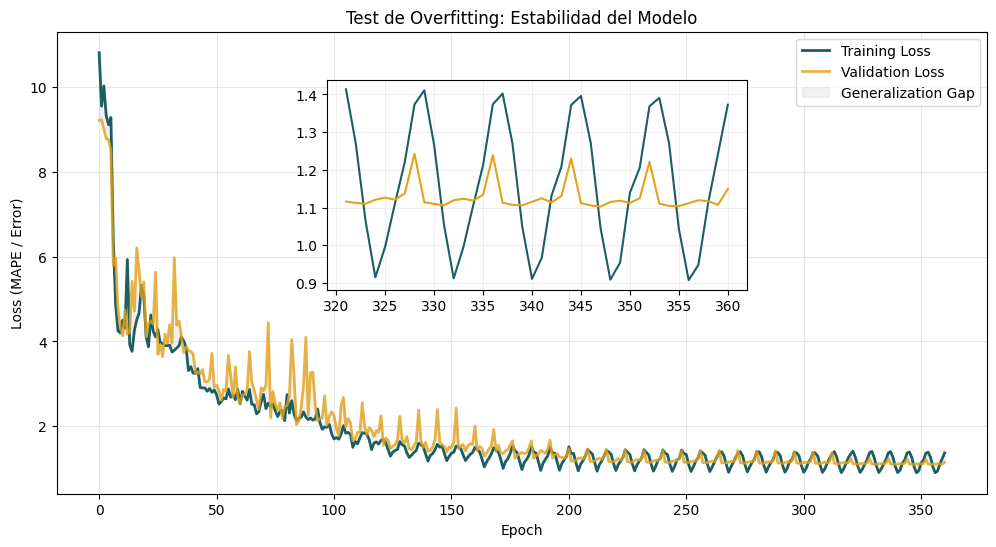

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler

# --- TU ESTILO ---
servicecolors = ["#1b5e63", "#e3a21a", "#d64541", "#7cb342", "#6d4c41"]
plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)



# 2. CÁLCULO DEL GAP DE GENERALIZACIÓN
# Diferencia porcentual entre lo que sabe (train) y lo que generaliza (val)
df['gap'] = (df['val_loss'] - df['loss']).abs()
gap_medio = df['gap'].tail(20).mean() # Miramos las últimas 20 épocas

# 3. VISUALIZACIÓN
plt.figure(figsize=(12, 6))

# Curvas principales
plt.plot(df['epoch'], df['loss'], label='Training Loss', linewidth=2, color=servicecolors[0])
plt.plot(df['epoch'], df['val_loss'], label='Validation Loss', linewidth=2, color=servicecolors[1], alpha=0.8)

# Sombreado del área entre curvas (El "Gap")
plt.fill_between(df['epoch'], df['loss'], df['val_loss'], color='gray', alpha=0.1, label='Generalization Gap')

plt.title(f"Test de Overfitting: Estabilidad del Modelo")
plt.xlabel("Epoch")
plt.ylabel("Loss (MAPE / Error)")
plt.legend()
plt.grid(True, alpha=0.3)

# Zoom en las últimas épocas para ver la convergencia fina
plt.axes([0.35, 0.45, 0.35, 0.35]) # Mini-gráfico interno
plt.plot(df['epoch'].tail(40), df['loss'].tail(40), color=servicecolors[0])
plt.plot(df['epoch'].tail(40), df['val_loss'].tail(40), color=servicecolors[1])
plt.grid(True, alpha=0.2)

plt.show()


In [4]:
import tensorflow as tf


import os
os.system("../")
from delay_model import RouteNet_Fermi
batch_size = 4
max_num_models = 7
embedding_dim = 32  # dimensión del estado oculto

# Datos de ejemplo (todos con shape (batch_size, 1))
traffic = tf.random.uniform((batch_size, 1))
packets = tf.random.uniform((batch_size, 1))
model = tf.constant([0, 4, 2, 1])  # shape (batch_size,)
eq_lambda = tf.random.uniform((batch_size, 1))
avg_pkts_lambda = tf.random.uniform((batch_size, 1))
exp_max_factor = tf.random.uniform((batch_size, 1))
pkts_lambda_on = tf.random.uniform((batch_size, 1))
avg_t_off = tf.random.uniform((batch_size, 1))
avg_t_on = tf.random.uniform((batch_size, 1))
ar_a = tf.random.uniform((batch_size, 1))
sigma = tf.random.uniform((batch_size, 1))

# z_score dummy (media, std)
z_score = {
    'traffic': (0.5, 0.2),
    'packets': (0.5, 0.2),
    'eq_lambda': (0.5, 0.2),
    'avg_pkts_lambda': (0.5, 0.2),
    'exp_max_factor': (0.5, 0.2),
    'pkts_lambda_on': (0.5, 0.2),
    'avg_t_off': (0.5, 0.2),
    'avg_t_on': (0.5, 0.2),
    'ar_a': (0.5, 0.2),
    'sigma': (0.5, 0.2),
}

# One-hot
model_oh = tf.one_hot(model, max_num_models)  # (batch_size, max_num_models)

# Concatenación
concat = tf.concat([
    (traffic - z_score['traffic'][0]) / z_score['traffic'][1],
    (packets - z_score['packets'][0]) / z_score['packets'][1],
    model_oh,
    (eq_lambda - z_score['eq_lambda'][0]) / z_score['eq_lambda'][1],
    (avg_pkts_lambda - z_score['avg_pkts_lambda'][0]) / z_score['avg_pkts_lambda'][1],
    (exp_max_factor - z_score['exp_max_factor'][0]) / z_score['exp_max_factor'][1],
    (pkts_lambda_on - z_score['pkts_lambda_on'][0]) / z_score['pkts_lambda_on'][1],
    (avg_t_off - z_score['avg_t_off'][0]) / z_score['avg_t_off'][1],
    (avg_t_on - z_score['avg_t_on'][0]) / z_score['avg_t_on'][1],
    (ar_a - z_score['ar_a'][0]) / z_score['ar_a'][1],
    (sigma - z_score['sigma'][0]) / z_score['sigma'][1],
], axis=1)

print("Shape final:", concat.shape)


path_embedding = tf.keras.layers.Dense(embedding_dim, activation='relu')

path_state = path_embedding(concat)

print("Embedding output shape:", path_state.shape)

2026-04-24 13:32:21.377884: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-24 13:32:21.377916: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
sh: 1: ../: Permission denied


ModuleNotFoundError: No module named 'delay_model'

In [ ]:
import pickle
import matplotlib.pyplot as plt

# 1. Cargar el historial
with open('./scratch_ckpt_all_cases/history_final.pkl', 'rb') as f:
    history = pickle.load(f)

# 2. Graficar
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Historial de Pérdida')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './scratch_ckpt_all_cases/history_final.pkl'

In [3]:
13*7*40*11 + 3*11*40*7



49280